# Southern Ocean Chlorophyll Visualization

This notebook explores chlorophyll-a (CHL) observations over the Southern Ocean. The workflow is:

1. Import scientific Python and mapping libraries.
2. Load and inspect the gridded CHL data.
3. Select dates, depths, or regions and prepare the array for plotting.
4. Draw maps, time series, and summary figures.

## How to read the outputs

- A colour map shows the spatial distribution of CHL. Each coloured grid cell is a data value at a longitude and latitude.
- A time-series plot shows how the selected spatial average or point changes with time.
- A regional or seasonal mean reduces many grid cells to one representative value, which is useful for comparing areas or periods.
- Blank or white areas usually indicate missing values, land, clouds, sea ice, or a mask applied by the source dataset.

Check the units, colour-bar label, date range, and map extent before interpreting any figure. The first data-loading cells may use paths from the original research workspace, so update those paths if the data are stored elsewhere.

In [18]:
import sys
print(sys.executable)

/home/ubuntu/miniconda3/bin/python


In [2]:
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
import matplotlib.path as mpath
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import xarray as xr
from matplotlib.lines import Line2D
# To avoid warning messages
import warnings
warnings.filterwarnings('ignore')

## Load and inspect the CHL dataset

The next cells open the chlorophyll dataset and inspect its dimensions, coordinates, variable names, and missing values. This check is important before plotting because it tells us which dimensions can be selected and what units the colour scale should use.

In [5]:
# Load chl-a data as xarray dataset
ds = xr.open_dataset('/home/ubuntu/DATA/extracted/merged/merged_oc.nc').sel(time= slice('1998-01-31', '2021-12-31'))
ds

<xarray.Dataset>
Dimensions:      (time: 288, lon: 8640, lat: 1155)
Coordinates:
  * time         (time) datetime64[ns] 1998-01-31 1998-02-28 ... 2021-12-31
  * lon          (lon) float32 -180.0 -179.9 -179.9 -179.9 ... 179.9 179.9 180.0
  * lat          (lat) float32 -36.9 -36.94 -36.98 ... -84.9 -84.94 -84.98
Data variables:
    spatial_ref  (time) int64 ...
    CHL          (time, lat, lon) float32 ...

In [6]:
ds_mean = ds.mean(dim='time')
ds_mean

<xarray.Dataset>
Dimensions:      (lon: 8640, lat: 1155)
Coordinates:
  * lon          (lon) float32 -180.0 -179.9 -179.9 -179.9 ... 179.9 179.9 180.0
  * lat          (lat) float32 -36.9 -36.94 -36.98 ... -84.9 -84.94 -84.98
Data variables:
    spatial_ref  float64 0.0
    CHL          (lat, lon) float32 nan nan nan nan nan ... nan nan nan nan nan

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import pandas as pd
# Define the color map
color_values = [
    [147,0,108], [111,0,144], [72,0,183], [33,0,222], [0,10,255], [0,74,255],
    [0,144,255], [0,213,255], [0,255,215], [0,255,119], [0,255,15], [96,255,0],
    [200,255,0], [255,235,0], [255,183,0], [255,131,0], [255,79,0], [255,31,0],
    [230,0,0], [165,0,0], [105,0,0]
]
sample_values = [0.0105927390978, 0.01511153517746066, 0.02218493234759939,
                 0.03259381777070279, 0.047886418593687446, 0.06831451603621097,
                 0.10029112852033921, 0.1473464383750438, 0.2164794954661175,
                 0.30882852380362497, 0.4533847704508146, 0.6661070836975002,
                 0.9786359751581525, 1.3961169989723918, 2.049610500045872,
                 3.011261431529367, 4.424106633340013, 6.311407543621453,
                 9.265646919990738, 13.612969492356, 20.0]
cmap = colors.ListedColormap(np.array(color_values)/255.0)
norm = colors.BoundaryNorm(sample_values, len(sample_values))

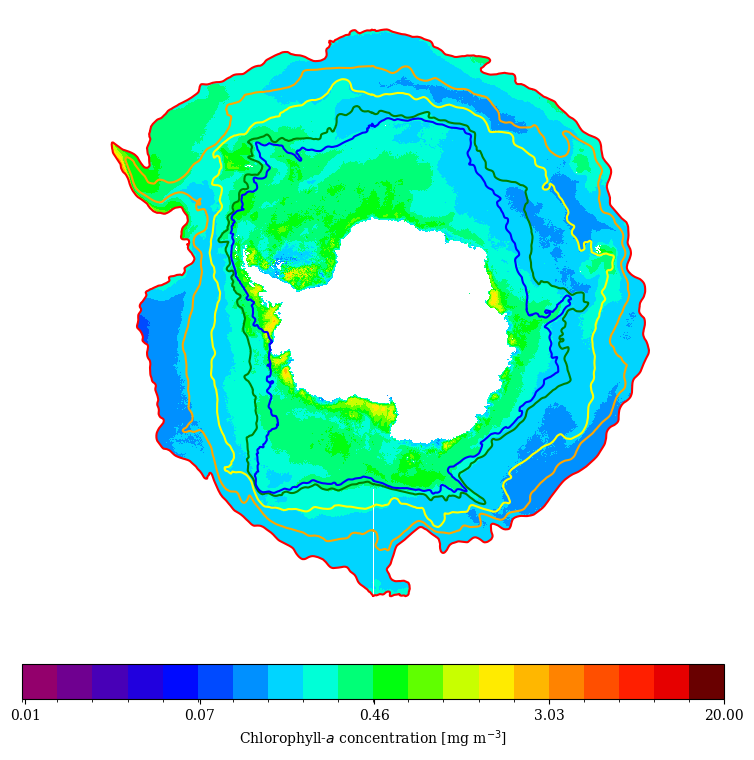

In [30]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
stf = pd.read_csv('/home/ubuntu/DATA/front/NB.txt', header=None, sep='\s+', na_values='%',
                  names=['lon', 'lat'])
saf = pd.read_csv('/home/ubuntu/DATA/front/saf.txt', header=None, sep='\s+', na_values='%',
                  names=['lon', 'lat'])
pf = pd.read_csv('/home/ubuntu/DATA/front/pf.txt', header=None, sep='\s+', na_values='%',
                 names=['lon', 'lat'])
saccf = pd.read_csv('/home/ubuntu/DATA/front/saccf.txt', header=None, sep='\s+', na_values='%',
                    names=['lon', 'lat'])
sbdy = pd.read_csv('/home/ubuntu/DATA/front/SB.txt', header=None, sep='\s+', na_values='%',
                   names=['lon', 'lat'])

plt.plot(stf['lon'], stf['lat'], color='Red', transform=ccrs.PlateCarree(), label='Northern Boundary')
plt.plot(saf['lon'], saf['lat'], color='Orange', transform=ccrs.PlateCarree(), label='Subantarctic Front')
plt.plot(pf['lon'], pf['lat'], color='Yellow', transform=ccrs.PlateCarree(), label='Polar Front')
plt.plot(saccf['lon'], saccf['lat'], color='Green', transform=ccrs.PlateCarree(), label='Southern ACC Front')
plt.plot(sbdy['lon'], sbdy['lat'], color='Blue', transform=ccrs.PlateCarree(), label='Southern Boundary')

im = ax.pcolormesh(ds_mean.lon, ds_mean.lat, ds_mean.CHL.values, cmap=cmap, norm=norm,
                   transform=ccrs.PlateCarree())

# Create the color bar
cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.01, orientation='horizontal')
cbar.ax.set_xlabel('Chlorophyll-${a}$ concentration [mg m$^{-3}$]')
tick_locs = [0.011, 0.07, 0.46, 3.03, 20]
tick_labels = [f"{loc:.2f}" for loc in tick_locs]
cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)

plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = "serif"
plt.axis('off')
# Show the plot
plt.tight_layout()
#plt.savefig('fig-2_Trend.jpg', dpi=600)

## First spatial CHL map

This block converts the selected CHL grid into a map. Compare the geographic pattern with the colour bar, and check that the map projection and longitude/latitude coordinates are aligned.

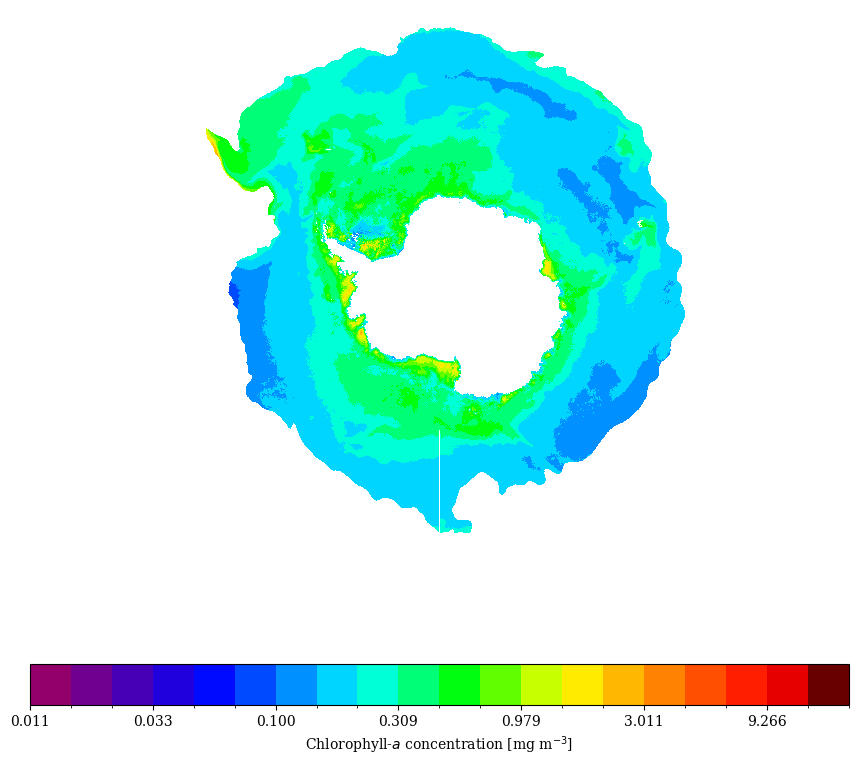

In [23]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.path as mpath
from matplotlib.lines import Line2D

plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
im = ax.pcolormesh(ds_mean.lon, ds_mean.lat, ds_mean.CHL.values, cmap=cmap, norm=norm,
                   transform=ccrs.PlateCarree())

# Create the color bar
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.1, orientation='horizontal')
cbar.ax.set_xlabel('Chlorophyll-${a}$ concentration [mg m$^{-3}$]')
plt.rcParams['font.size'] = 10
plt.rcParams["font.family"] = "serif"
plt.axis('off')
# Show the plot
plt.tight_layout()